# (07) pairwise corrs: (16, 20.0)

project = ```iP-VAE```, host = ```chewie```, device = ```cuda:0```

**Motivation**: <br>


In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, '_IterativeVAE'))
from figures.analysis import plot_convergence
from figures.imgs import plot_weights
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
from base.helper import ParameterGrid
from utils.animation import show_movie


device_idx = 0
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:0  ———  host: chewie

## Setup feeder params

In [3]:
# Define parameter values

theta_delta = 15
theta_num = int(np.ceil(180 / theta_delta)) + 1
theta = np.linspace(0, 180, theta_num)

s_freq_min = 0.5
s_freq_max = 10.0
s_freq_delta = 0.5
s_freq_num = (s_freq_max - s_freq_min) / s_freq_delta
s_freq_num = int(np.ceil(s_freq_num)) + 1
s_freq = np.linspace(
    start=s_freq_min,
    stop=s_freq_max,
    num=s_freq_num,
)
s_freq = np.insert(s_freq, obj=0, values=0.1)

params = {
    'contrast': [1.0],
    's_freq': np.round(s_freq, decimals=2),
    'theta': np.round(theta, decimals=2),
}
print(params)

{
    'contrast': [1.0],
    's_freq': array([ 0.1,  0.5,  1. ,  1.5,  2. ,  2.5,  3. ,  3.5,  4. ,  4.5,  5. ,
        5.5,  6. ,  6.5,  7. ,  7.5,  8. ,  8.5,  9. ,  9.5, 10. ]),
    'theta': array([  0.,  15.,  30.,  45.,  60.,  75.,  90., 105., 120., 135., 150.,
       165., 180.])
}

### make param grid

In [4]:
grid = ParameterGrid(params)
param_vectors = grid.get_param_vectors()

len(grid)

273

### Make feeder

In [5]:
n_frames_for_full_cycle = 500

feeder_kws = dict(
    npix=16,
    #
    theta=param_vectors['theta'],
    s_freq=param_vectors['s_freq'],
    t_freq=1 / n_frames_for_full_cycle,
    contrast=param_vectors['contrast'],
    normalize_coords=True,
    #
    device=device,
    flatten=True,
)
feeder = FEEDER_CLASSES['drifting-grating'](**feeder_kws)

## Load trainer

In [6]:
model_name = 'poisson_vH16_t-16_z-[512]_cl-10,10_<grad|lin>'
fit_name = 'b200-ep300-lr(0.005)_beta(20:0.1)_temp(0.01:0.5)_gr(500)_(2025_03_02,16:19)'

tr, meta = load_model(f"{model_name}/{fit_name}", device)
u0 = tonp(tr.model.layer.u_init[0].squeeze())
order = np.argsort(u0)

meta['checkpoint']

300

### Xtract ftrs

In [7]:
%%time


trial_timepoints = range(
    n_frames_for_full_cycle,
    n_frames_for_full_cycle * 2,
)
n_trials = 200

spk_counts_all = []
for i in tqdm(range(n_trials)):
    tr.model.cfg.set_seeds(i)

    output = tr.model.xtract_ftr(
        feeder=FEEDER_CLASSES['drifting-grating'](**feeder_kws),
        seq=range(2 * n_frames_for_full_cycle),
        return_extras=['samples'],
    ).stack()

    spks = output['samples'][:, trial_timepoints]
    spk_counts_all.append(tonp(spks.sum(1)))

spk_counts_all = np.stack(spk_counts_all)
spk_counts_all.shape

100%|█████████████████████████████████████████| 200/200 [36:18<00:00, 10.89s/it]

CPU times: user 36min 9s, sys: 845 ms, total: 36min 10s
Wall time: 36min 18s


(200, 273, 512)

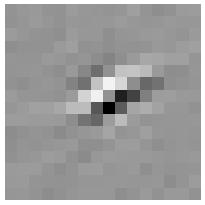

In [15]:
neuron_i = 303

_ = tr.model.show(order=[order[neuron_i]], nrows=1, dpi=50, method='abs-max')

In [16]:
shape = (n_trials, *grid.param_lengths)

tuning_curve = spk_counts_all[..., neuron_i]
tuning_curve = tuning_curve.reshape(shape)
tuning_curve = tuning_curve.mean(0)

tuning_curve.shape

(1, 21, 13)

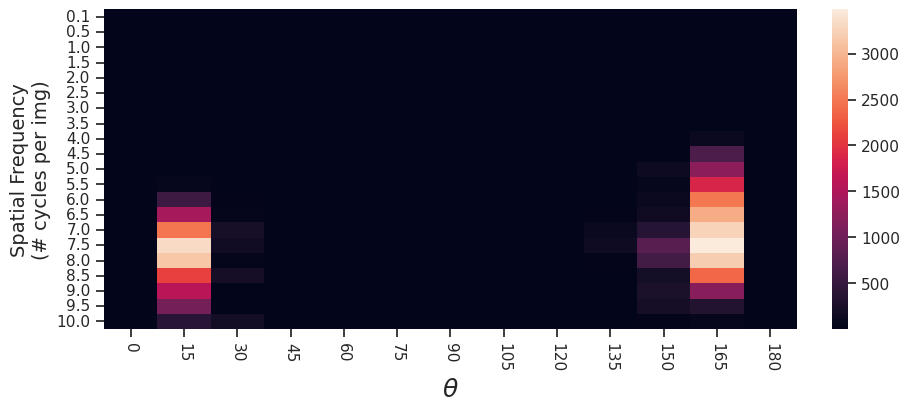

In [17]:
fig, ax = create_figure(1, 1, (9, 4))
sns.heatmap(data=tuning_curve[0, ...], ax=ax)

ax.set_ylabel('Spatial Frequency\n(# cycles per img)', fontsize=14)
ax.set_xlabel(r'$\theta$', fontsize=18)


ax.set_yticks(np.array(range(len(s_freq))) + 0.5)
ax.set_yticklabels(s_freq, rotation=0)

ax.set_xticks(np.array(range(len(theta))) + 0.5)
ax.set_xticklabels([str(int(angle)) for angle in theta], rotation=-90)

plt.show()

In [18]:
favorite_idx = np.argmax(tuning_curve)
favorite_params = grid[favorite_idx]

favorite_params

{'contrast': 1.0, 's_freq': 7.5, 'theta': 165.0}

In [19]:
favorite_s_freq_idx = grid.param_dict['s_freq'] == favorite_params['s_freq']
favorite_s_freq_idx = np.where(favorite_s_freq_idx)[0].item()

favorite_s_freq_idx

15

In [20]:
tuning_curve_theta = tuning_curve[0, favorite_s_freq_idx]

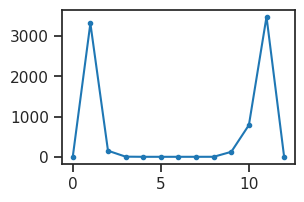

In [21]:
plot(tuning_curve_theta, marker='.');

In [22]:
tr.model.cfg.seed

199

In [23]:
shape = (*grid.param_lengths, spk_counts_all.shape[-1])
tuning_curve_all = spk_counts_all.mean(0).reshape(shape)
tuning_curve_all = tuning_curve_all[0]  # only one contrast

tuning_curve_all.shape

(21, 13, 512)

In [24]:
tuning_curves_theta = []
favorites_df = collections.defaultdict(list)
for neuron_i in range(tuning_curve_all.shape[-1]):
    favorite_idx = np.argmax(tuning_curve_all[..., neuron_i])
    favorite_params = grid[favorite_idx]

    favorite_s_freq_idx = grid.param_dict['s_freq'] == favorite_params['s_freq']
    favorite_s_freq_idx = np.where(favorite_s_freq_idx)[0].item()
    tuning_theta = tuning_curve_all[favorite_s_freq_idx, :, neuron_i]
    tuning_curves_theta.append(tuning_theta)
    
    favorites_df['neruon_i'].append(neuron_i)
    for k, v in favorite_params.items():
        favorites_df[k].append(v)

tuning_curves_theta = np.stack(tuning_curves_theta, axis=1)
favorites_df = pd.DataFrame(favorites_df)

tuning_curves_theta.shape, favorites_df.shape

((13, 512), (512, 4))

In [25]:
def plot_tuning_hist(name, color='C0'):
    bins = grid.param_dict[name].copy()
    delta = bins[1] - bins[0]
    bins = np.insert(bins, 0, -delta)
    bins += delta / 2
    
    fig, ax = create_figure(1, 1, (3, 2))
    sns.histplot(favorites_df[name].values, label=name, bins=bins, color=color, ax=ax)
    ax.legend()
    plt.show()

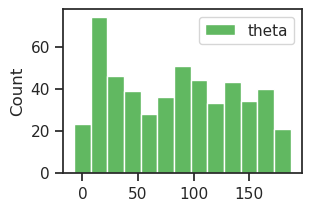

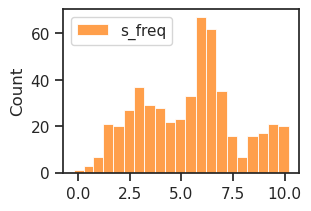

In [26]:
plot_tuning_hist('theta', 'C2')
plot_tuning_hist('s_freq', 'C1')

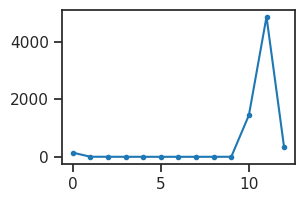

In [27]:
neuron_i = 54

plt.plot(tuning_curves_theta[:, neuron_i], marker='.')

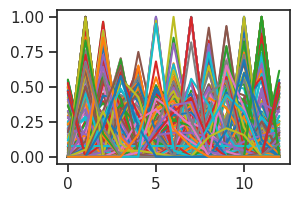

In [28]:
plt.plot(tuning_curves_theta / tuning_curves_theta.sum(0, keepdims=True));

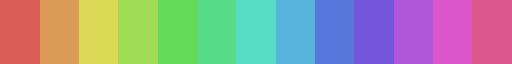

In [29]:
periodic_cmap, base_colors = get_periodic_palette(
    len(grid.param_dict['theta']))

periodic_cmap

In [30]:
len(base_colors)

13

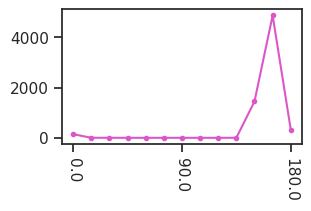

In [31]:
fig, ax = create_figure()

neuron_i = 54
x2p = tuning_curves_theta[..., neuron_i]
ax.plot(x2p, color=base_colors[np.argmax(x2p)], marker='.')

xticks, xticklabels = zip(*[
    (i, v) for i, v in
    enumerate(grid.param_dict['theta'])
    if i % 6 == 0
])
ax.set(xticks=xticks, xticklabels=xticklabels)
ax.tick_params(axis='x', labelrotation=-90)

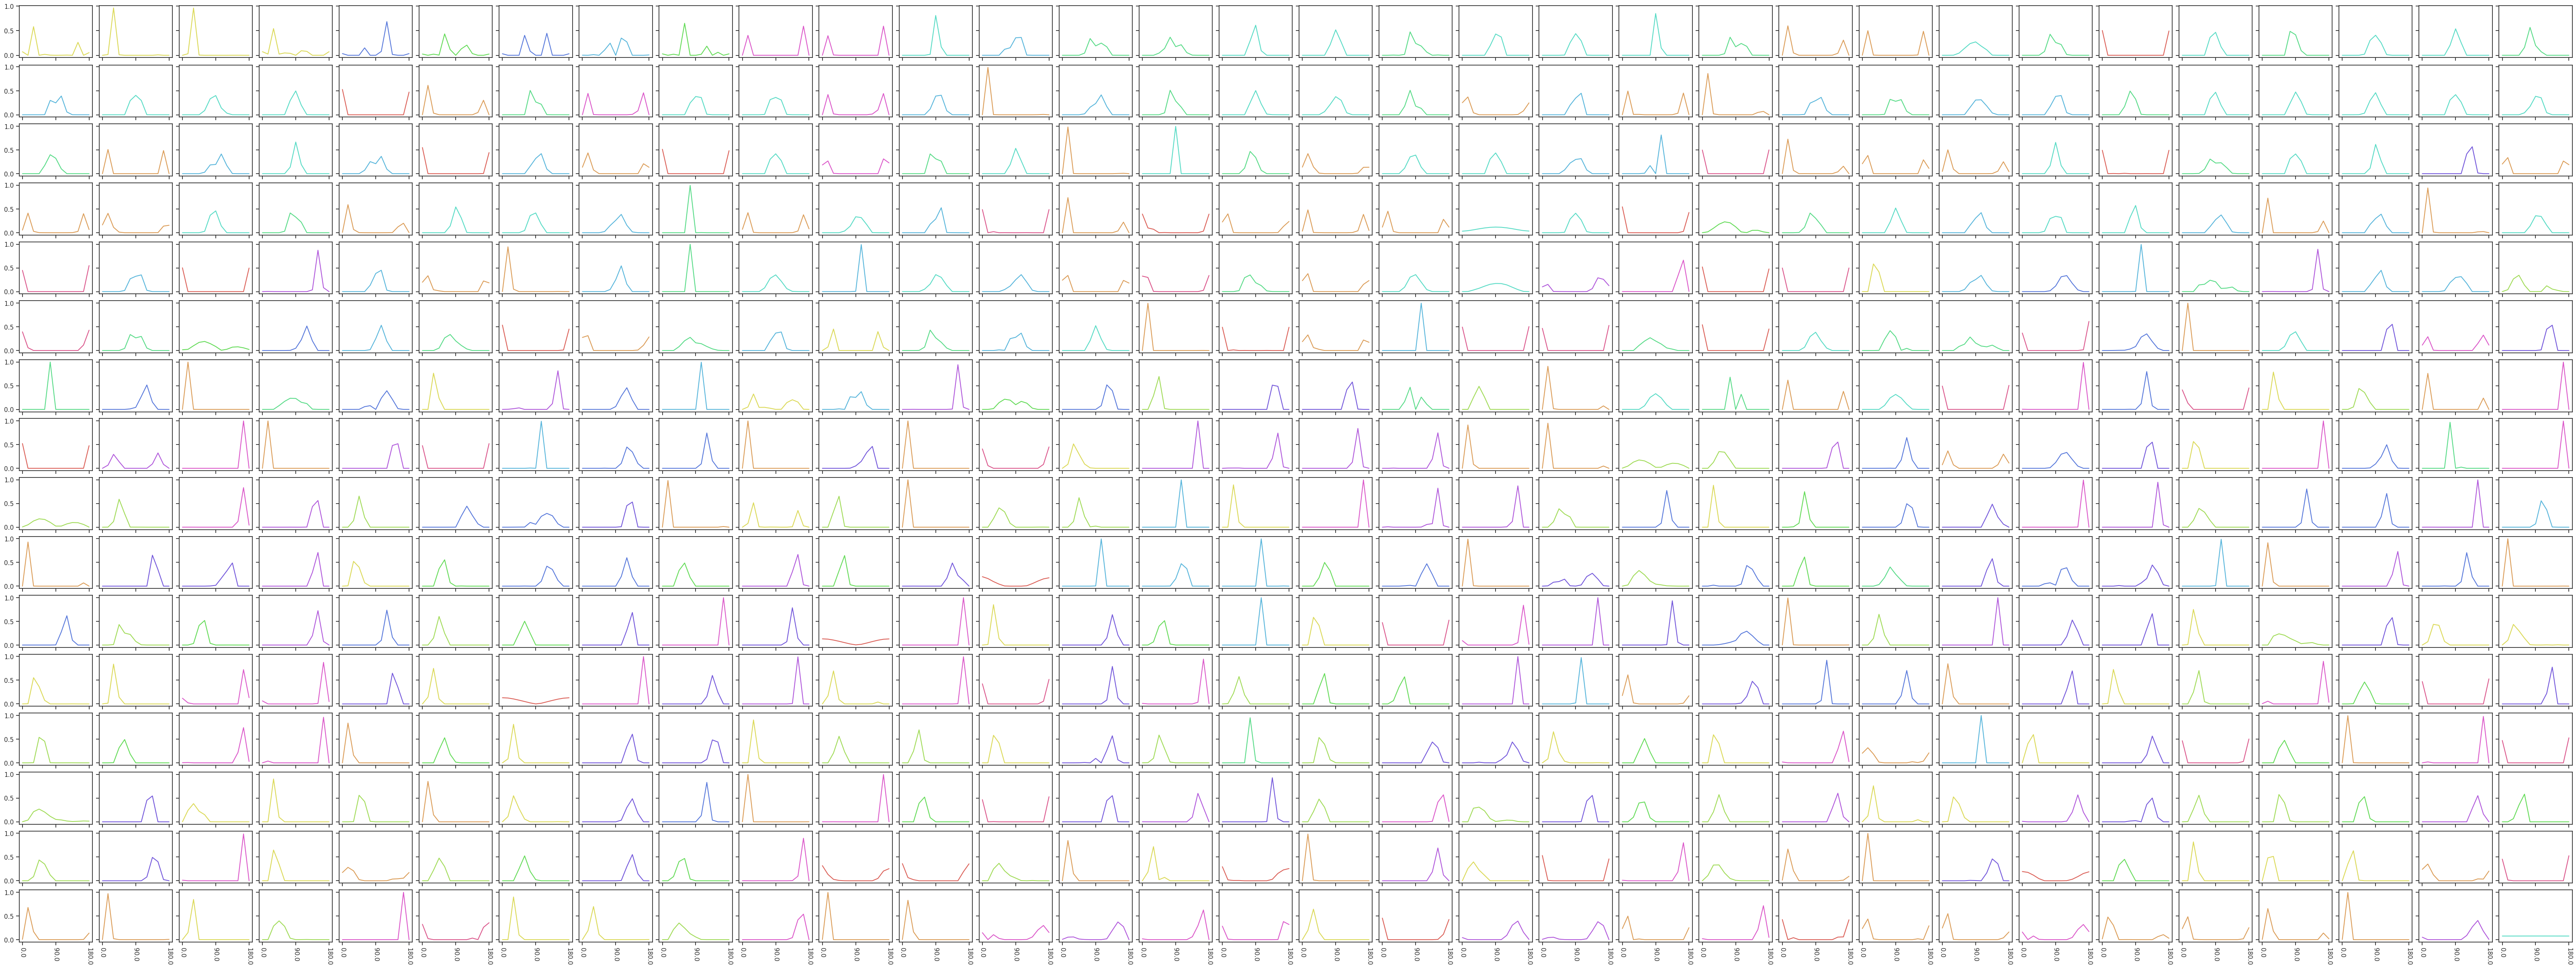

In [33]:
nrows = 16
ncols = int(np.ceil(tuning_curves_theta.shape[-1] / nrows))

fig, axes = create_figure(nrows, ncols, (ncols * 2.0, nrows * 1.5), sharex='all', sharey='row')
for i, ax in enumerate(axes.flat):
    x2p = tuning_curves_theta[..., order[i]]
    x2p /= x2p.sum()
    ax.plot(x2p, color=base_colors[np.argmax(x2p)])


xticks, xticklabels = zip(*[
    (i, v) for i, v in
    enumerate(grid.param_dict['theta'])
    if i % 6 == 0
])
for ax in axes[-1]:
    ax.set(xticks=xticks, xticklabels=xticklabels)
    ax.tick_params(axis='x', labelrotation=-90)

In [34]:
fig.savefig(pjoin(fig_base_dir, 'tuning_theta.pdf'), bbox_inches='tight')
# fig.savefig(pjoin(fig_base_dir, 'tuning_theta.png'), bbox_inches='tight', dpi=300)

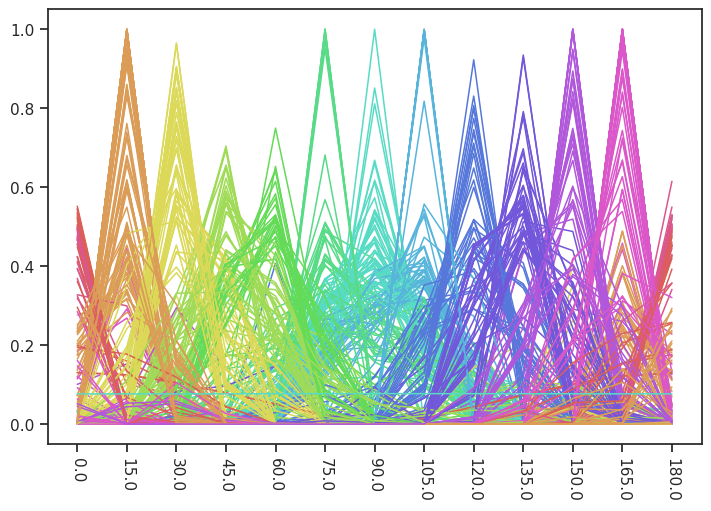

In [43]:
fig, ax = create_figure(1, 1, (7, 5))
for i in range(tuning_curves_theta.shape[-1]):
    x2p = tuning_curves_theta[..., order[i]]
    x2p /= x2p.sum()
    ax.plot(x2p, color=base_colors[np.argmax(x2p)], lw=1.1)

xticks, xticklabels = zip(*[
    (i, v) for i, v in
    enumerate(grid.param_dict['theta'])
    if i % 1 == 0
])
ax.set(xticks=xticks, xticklabels=xticklabels)
ax.tick_params(axis='x', labelrotation=-90)

fig.savefig(pjoin(fig_base_dir, 'tuning_theta_overlaid.pdf'), bbox_inches='tight')

plt.show()

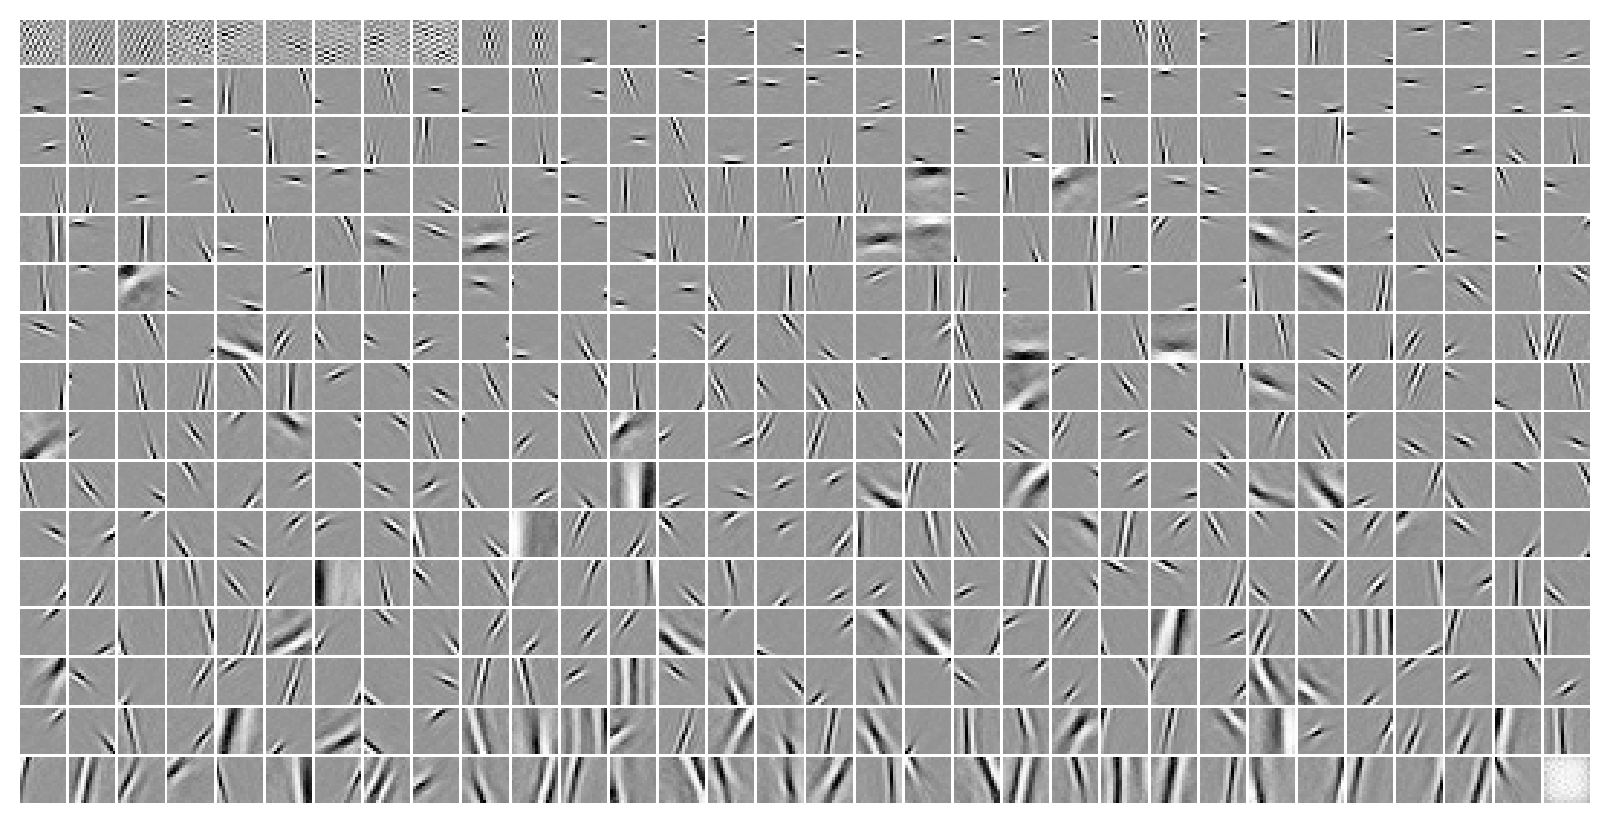

In [44]:
tr.model.show(order=order, method='abs-max');

In [31]:
corr_signal = 1 - sp_dist.squareform(sp_dist.pdist(
    X=tuning_curves_theta.T,
    metric='correlation',
))
corr_signal.shape

(512, 512)

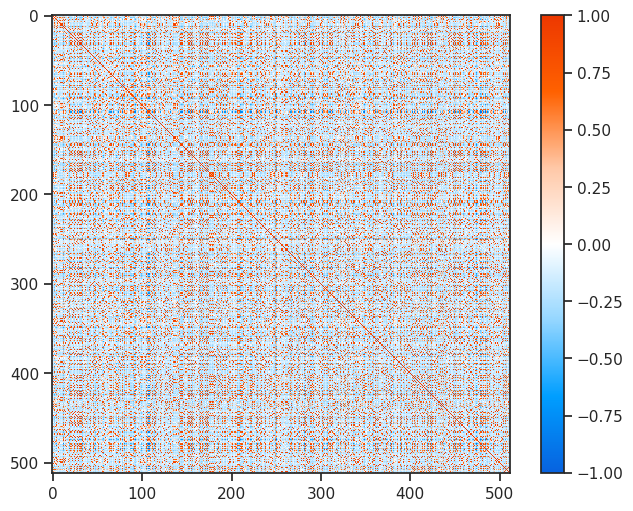

In [32]:
fig, ax = create_figure(1, 1, (6.5, 5))
im = ax.imshow(corr_signal, cmap=rd_or_bu(reverse=True), vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)
plt.show()

In [33]:
w = tr.model.layer.get_weight()
phi_t_phi = tonp(w.T @ w)

corr_phi = 1 - sp_dist.squareform(sp_dist.pdist(
    X=tonp(w.T),
    metric='correlation',
))

phi_t_phi.shape, corr_phi.shape

((512, 512), (512, 512))

In [34]:
r_between_corrsignal_phitphi = sp_stats.pearsonr(
    corr_signal[np.triu_indices(len(corr_signal), k=1)],
    phi_t_phi[np.triu_indices(len(phi_t_phi), k=1)],
)
print(r_between_corrsignal_phitphi)

PearsonRResult(statistic=-0.08080159561252645, pvalue=2.335629960673062e-188)

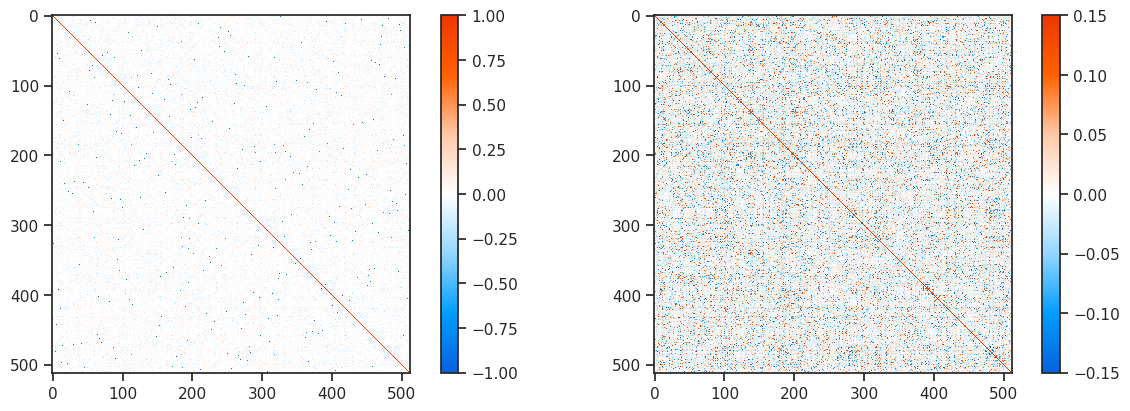

In [35]:
fig, axes = create_figure(1, 2, (12, 4))
im = axes[0].imshow(corr_phi, cmap=rd_or_bu(reverse=True), vmin=-1, vmax=1)
plt.colorbar(im, ax=axes[0])
im = axes[1].imshow(corr_phi, cmap=rd_or_bu(reverse=True), vmin=-0.15, vmax=0.15)
plt.colorbar(im, ax=axes[1])
plt.show()

In [36]:
r_between_corrsignal_corrphi = sp_stats.pearsonr(
    corr_signal[np.triu_indices(len(corr_signal), k=1)],
    corr_phi[np.triu_indices(len(corr_phi), k=1)],
)
print(r_between_corrsignal_corrphi)

PearsonRResult(statistic=-0.08068564818893113, pvalue=8.02397288665245e-188)

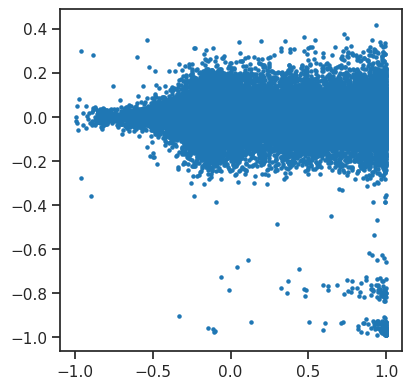

In [37]:
fig, ax = create_figure(1, 1, (4, 4))
plt.scatter(
    x=corr_signal[np.triu_indices(len(corr_signal), k=1)],
    y=corr_phi[np.triu_indices(len(corr_phi), k=1)],
    s=5,
)
ax_square(ax)
plt.show()

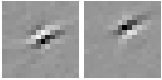

In [38]:
selected_neurons = [303, 303 + 32]

_ = tr.model.show(order=order[selected_neurons], nrows=1, dpi=20, method='abs-max')

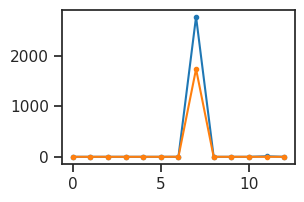

In [40]:
plot(tuning_curves_theta[:, order[selected_neurons]], marker='.');

In [42]:
msg = f"signal correlation: {corr_signal[order[selected_neurons[0]], order[selected_neurons[1]]]:0.3f}"
msg += f",  phi correlation: {corr_phi[order[selected_neurons[0]], order[selected_neurons[1]]]:0.3f}"

print(msg)

signal correlation: 1.000,  phi correlation: -0.069

In [43]:
w = tonp(tr.model.layer.get_weight())
w.shape

(256, 512)

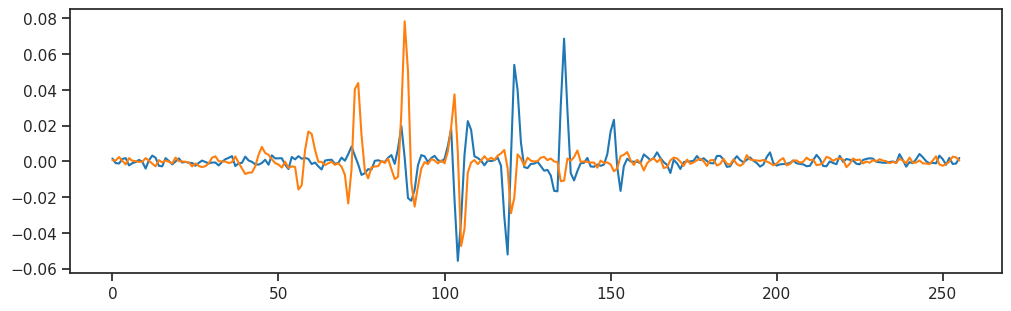

In [44]:
fig, ax = create_figure(1, 1, (10, 3))
ax.plot(w[:, order[selected_neurons[0]]])
ax.plot(w[:, order[selected_neurons[1]]])
plt.show()

In [45]:
favorites_df.loc[favorites_df['neruon_i'].isin(order[selected_neurons])]

,neruon_i,contrast,s_freq,theta
206,206,1.0,9.5,105.0
345,345,1.0,10.0,105.0


In [46]:
selected_s_freqs = [9.5, 10.0]
selected_thetas = [105.0]

selected_df = []

for trial_i in range(n_trials):
    for stim_i in range(len(grid)):
        params = grid[stim_i]
        cond_accept = (
            params['s_freq'] in selected_s_freqs
            and params['theta'] in selected_thetas
        )
        if not cond_accept:
            continue
        params = {
            k: [v] * spk_counts_all.shape[-1]
            for k, v in params.items()
        }
        params = {
            **params,
            'neuron': range(spk_counts_all.shape[-1]),
            'counts': spk_counts_all[trial_i, stim_i],
        }
        selected_df.append(params)

selected_df = pd.DataFrame(merge_dicts(selected_df))

In [47]:
df2p = []
for i in order[selected_neurons]:
    _df = selected_df.loc[selected_df['neuron'] == i]
    _df = _df.rename(columns={'counts': f'counts_{i}'})
    _df = _df.drop(columns='neuron')
    df2p.append(_df)

In [48]:
shared_cols = set.intersection(*(set(df.columns) for df in df2p))
df2p = pd.concat([
    df.set_index(list(shared_cols))
    for df in df2p
], axis=1).reset_index()

In [49]:
df2p

,theta,contrast,s_freq,counts_345,counts_206
0,105.0,1.0,9.5,2236.0,1750.0
1,105.0,1.0,10.0,2594.0,1707.0
2,105.0,1.0,9.5,2168.0,1739.0
3,105.0,1.0,10.0,2695.0,1802.0
4,105.0,1.0,9.5,2035.0,1822.0
...,...,...,...,...,...
395,105.0,1.0,10.0,2788.0,1674.0
396,105.0,1.0,9.5,2155.0,1790.0
397,105.0,1.0,10.0,2722.0,1698.0
398,105.0,1.0,9.5,2137.0,1729.0


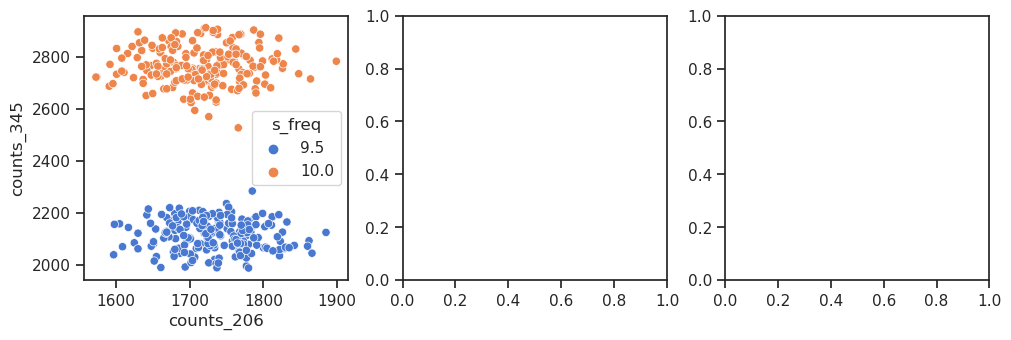

In [55]:
fig, axes = create_figure(1, 3, (10, 3.5))


_df = df2p.loc[df2p['theta'] == 105.0]

# _df = df2p.loc[
#     (df2p['theta'] == 105.0) &
#     (df2p['s_freq'] == 9.5)
# ]

sns.scatterplot(
    data=_df,
    x='counts_206',
    y='counts_345',
    hue='s_freq',
    palette='muted',
    ax=axes[0],
)
ax_square(axes)
plt.show()

In [104]:
df2p = selected_df.loc[selected_df['neuron'].isin(neurons)]
df2p.shape

(1600, 5)

In [105]:
df2p

,contrast,s_freq,theta,neuron,counts
130,1.0,4.5,0.0,130,2861.0
170,1.0,4.5,0.0,170,3977.0
642,1.0,4.5,180.0,130,2660.0
682,1.0,4.5,180.0,170,4658.0
1154,1.0,7.5,0.0,130,5085.0
...,...,...,...,...,...
408234,1.0,4.5,180.0,170,4522.0
408706,1.0,7.5,0.0,130,5082.0
408746,1.0,7.5,0.0,170,4300.0
409218,1.0,7.5,180.0,130,5085.0


In [183]:
spk_counts_mean = spk_counts_all.mean(0)
spk_counts_var = spk_counts_all.var(0)

In [185]:
spk_counts_mean.shape, spk_counts_var.shape

((273, 512), (273, 512))

In [186]:
len(grid)

273

In [187]:
ff = spk_counts_var / spk_counts_mean

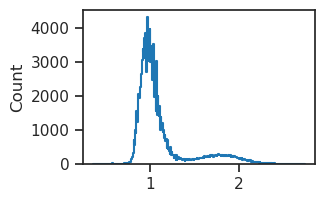

In [191]:
histplot(ff.ravel());

[(0.0, 10000.0), (0.0, 10000.0)]

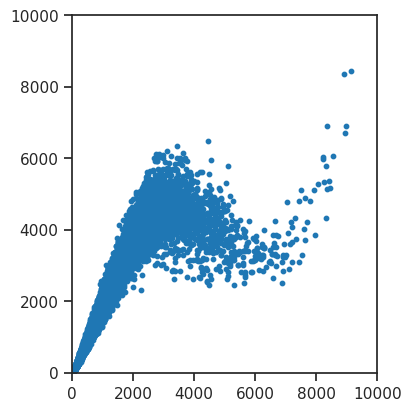

In [202]:
fig, ax = create_figure(1, 1, (4, 4))

ax.scatter(x=spk_counts_mean.ravel(), y=spk_counts_var.ravel(), s=10)
ax.set(xlim=(0, 10000), ylim=(0, 10000))

In [229]:
spk_counts_all.shape, len(grid)

((200, 273, 512), 273)

In [231]:
neuron_pairs = list(itertools.combinations(
    range(spk_counts_all.shape[-1]), 2))

corr_df = collections.defaultdict(list)

for stim_i in tqdm(range(len(grid))):
    noise_corr = 1 - sp_dist.squareform(sp_dist.pdist(
        X=spk_counts_all[:, stim_i].T,
        metric='correlation',
    ))
    for i, j in neuron_pairs:
        for k, v in grid[stim_i].items():
            corr_df[k].append(v)
        corr_df['cell_1'].append(i)
        corr_df['cell_2'].append(j)
        corr_df['noise_corr'].append(noise_corr[i, j])

corr_df = pd.DataFrame(corr_df)
corr_df.shape

100%|█████████████████████████████████████████| 273/273 [00:37<00:00,  7.29it/s]


(35712768, 6)

In [232]:
corr_df

,contrast,s_freq,theta,cell_1,cell_2,noise_corr
0,1.0,0.1,0.0,0,1,0.055128
1,1.0,0.1,0.0,0,2,0.004976
2,1.0,0.1,0.0,0,3,0.042104
3,1.0,0.1,0.0,0,4,-0.058583
4,1.0,0.1,0.0,0,5,-0.000867
...,...,...,...,...,...,...
35712763,1.0,10.0,180.0,508,510,0.072464
35712764,1.0,10.0,180.0,508,511,0.001790
35712765,1.0,10.0,180.0,509,510,0.129267
35712766,1.0,10.0,180.0,509,511,-0.087735


In [268]:
np.argsort(corr_phi[130])

array([306, 370, 475, 498, 102, 389, 397, 298,  54, 127, 170, 364, 485,
       183, 316, 104, 362, 287, 333, 334, 182, 400, 424,  12, 125, 106,
       318,   5, 281, 282, 305, 363, 162,  48, 176, 286, 185, 351, 328,
        98,  69, 169, 107, 277, 360, 294, 367, 511, 265, 315, 146, 411,
       352, 226,  89, 324, 491,   9, 174, 150, 323, 224, 368, 278, 358,
       178, 441, 217, 138, 335, 192, 103, 228, 279, 499,  74, 366,  81,
       114, 173, 393, 253, 154, 462,  75, 346, 303, 302, 161, 442,   3,
        64, 450,  44, 296, 248, 250, 446, 171,  15, 380, 307, 187,  39,
       510, 266, 230,  37, 199, 482, 115, 288, 160, 269, 452, 479, 200,
       396, 489, 164, 147, 456, 436, 227, 345,  66,  10, 433,  21, 148,
       435, 369, 276, 309, 321, 280, 466,  53, 205, 119, 290, 134, 465,
       507, 262, 447, 471, 459, 285, 196, 244, 428, 155,   8, 120, 468,
       246, 233, 509, 320, 483, 256, 100,  25,  65, 490, 128, 263, 348,
       222, 401,  28, 405, 137,   7,  78, 391, 418, 143, 112, 42

In [1]:
neurons = [120, 22]

_ = tr.model.show(order=neurons, nrows=1, dpi=20, method='abs-max')

NameError: name 'tr' is not defined

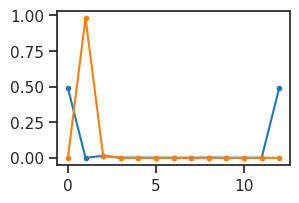

In [289]:
plot(tuning_curves_theta[:, neurons], marker='.');

In [290]:
msg = f"signal correlation: {corr_signal[neurons[0], neurons[1]]:0.3f}"
msg += f",  phi correlation: {corr_phi[neurons[0], neurons[1]]:0.3f}"

print(msg)

signal correlation: -0.127,  phi correlation: 0.136

In [295]:
_df = corr_df.loc[
    (corr_df['cell_1'] == sorted(neurons)[0]) &
    (corr_df['cell_2'] == sorted(neurons)[1])
]
_df = _df.pivot(columns='theta', index='s_freq', values='noise_corr')

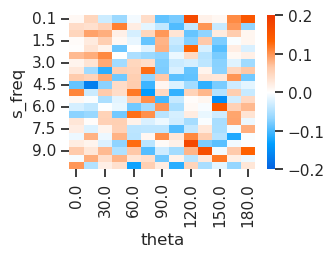

In [297]:
sns.heatmap(
    data=_df,
    cmap=rd_or_bu(reverse=True), 
    vmin=-0.2,
    vmax=0.2,
);

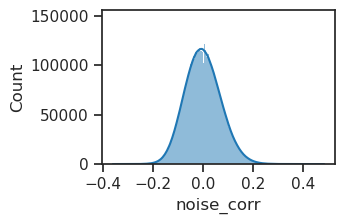

In [302]:
sns.histplot(data=corr_df, x='noise_corr', kde=True)
plt.show()

In [311]:
sorted_ids = np.argsort(corr_df['noise_corr'].values)

28294357

In [324]:
corr_df.iloc[sorted_ids[2]]

contrast        1.000000
s_freq          7.000000
theta          60.000000
cell_1         20.000000
cell_2        121.000000
noise_corr     -0.346133
Name: 24341906, dtype: float64

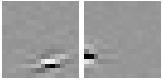

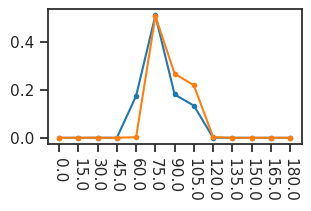

In [325]:
neurons = [20, 121]

_ = tr.model.show(order=neurons, nrows=1, dpi=20, method='abs-max')

fig, ax = create_figure()
ax.plot(tuning_curves_theta[:, neurons], marker='.')

xticks, xticklabels = zip(*[
    (i, v) for i, v in
    enumerate(grid.param_dict['theta'])
    if i % 1 == 0
])
ax.set(xticks=xticks, xticklabels=xticklabels)
ax.tick_params(axis='x', labelrotation=-90)

In [335]:
_df = corr_df.loc[
    (corr_df['cell_1'] == sorted(neurons)[0]) &
    (corr_df['cell_2'] == sorted(neurons)[1]) &
    (corr_df['s_freq'] == 7.0) &
    (corr_df['theta'] == 75)
]
# _df = _df.pivot(
#     columns='theta',
#     index='s_freq',
#     values='noise_corr',
# )
_df

,contrast,s_freq,theta,cell_1,cell_2,noise_corr
24472722,1.0,7.0,75.0,20,121,0.084727


0.08472684405734432

In [338]:
msg = f"signal corr: {corr_signal[neurons[0], neurons[1]]:0.3f}\n"
msg += f"noise corr: {_df['noise_corr'].values.item():0.3f}\n"
msg += f"phi corr: {corr_phi[neurons[0], neurons[1]]:0.3f}"

print(msg)

signal corr: 0.923
noise corr: 0.085
phi corr: 0.013

In [350]:
selected_s_freqs = [7.0]
selected_thetas = [75.0]

selected_df = []

for trial_i in range(n_trials):
    for stim_i in range(len(grid)):
        params = grid[stim_i]
        cond_accept = (
            params['s_freq'] in selected_s_freqs
            and params['theta'] in selected_thetas
        )
        if not cond_accept:
            continue
        params = {
            k: [v] * spk_counts_all.shape[-1]
            for k, v in params.items()
        }
        params = {
            **params,
            'neuron': range(spk_counts_all.shape[-1]),
            'counts': spk_counts_all[trial_i, stim_i],
        }
        selected_df.append(params)

selected_df = pd.DataFrame(merge_dicts(selected_df))

In [351]:
df2p = []
for i in neurons:
    _df = selected_df.loc[selected_df['neuron'] == i]
    _df = _df.rename(columns={'counts': f'counts_{i}'})
    _df = _df.drop(columns='neuron')
    df2p.append(_df)

In [352]:
shared_cols = set.intersection(*(set(df.columns) for df in df2p))
df2p = pd.concat([
    df.set_index(list(shared_cols))
    for df in df2p
], axis=1).reset_index()

In [353]:
df2p

,s_freq,contrast,theta,counts_20,counts_121
0,7.0,1.0,75.0,1911.0,599.0
1,7.0,1.0,75.0,1939.0,604.0
2,7.0,1.0,75.0,2024.0,570.0
3,7.0,1.0,75.0,2053.0,585.0
4,7.0,1.0,75.0,1881.0,583.0
...,...,...,...,...,...
195,7.0,1.0,75.0,2014.0,580.0
196,7.0,1.0,75.0,2097.0,610.0
197,7.0,1.0,75.0,1980.0,613.0
198,7.0,1.0,75.0,1866.0,628.0


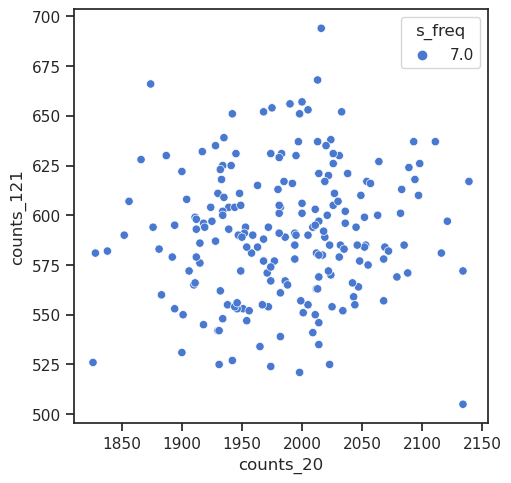

In [354]:
fig, ax = create_figure(1, 1, (5, 5))

# _df = df2p.loc[df2p['theta'] == 180.0]
_df = df2p.loc[
    (df2p['theta'] == 75.0) &
    (df2p['s_freq'] == 7.0)
]

sns.scatterplot(
    data=_df,
    x='counts_20',
    y='counts_121',
    hue='s_freq',
    palette='muted',
    ax=ax,
)
ax_square(ax)
plt.show()

In [214]:
r_between_corrsignal_corrphi = sp_stats.pearsonr(
    corr_noise[np.triu_indices(len(corr_noise), k=1)],
    corr_phi[np.triu_indices(len(corr_phi), k=1)],
)
print(r_between_corrsignal_corrphi)

PearsonRResult(statistic=0.005548192943350325, pvalue=0.04478224124304325)

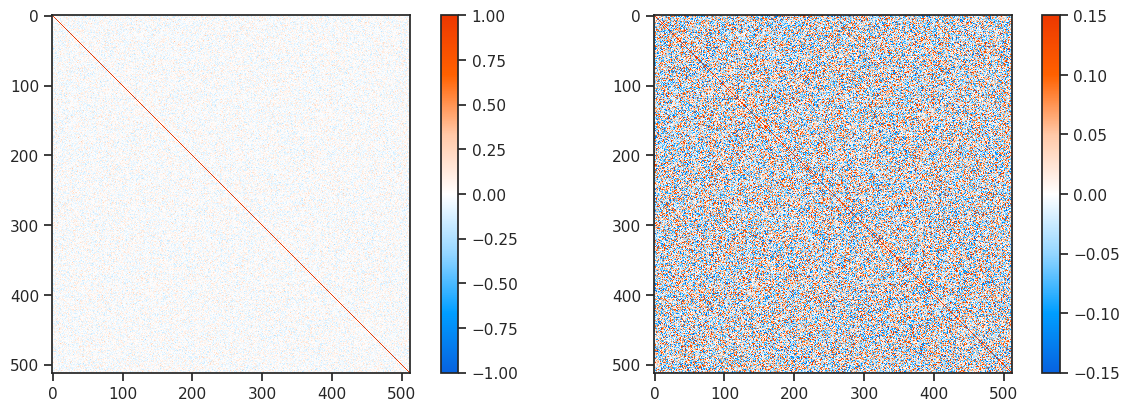

In [213]:
fig, axes = create_figure(1, 2, (12, 4))
im = axes[0].imshow(corr_noise, cmap=rd_or_bu(reverse=True), vmin=-1, vmax=1)
plt.colorbar(im, ax=axes[0])
im = axes[1].imshow(corr_noise, cmap=rd_or_bu(reverse=True), vmin=-0.15, vmax=0.15)
plt.colorbar(im, ax=axes[1])
plt.show()